# Scribble Conditioning Comparison — Unified Notebook v3

We compare **three scribble conditioning strategies** under a **neutral prompt**, across **four target distributions**:

| Experiment | Target distribution | Proxy N | SDEdit prompt |
|---|---|---|---|
| `50_50` | 50% man / 50% woman | 100 | Balanced |
| `25_75` | 25% man / 75% woman | 100 | Skewed |
| `gender_interp` | 4-class gender spectrum (each 25%) | 100 | Interpolation |
| `age_interp` | Uniform ages 40–80 (men), 3 img/age = 123 | 123 | Age |

**Conditions**
- `avg_scribble` — weighted pixel average of HED maps (by target fractions)
- `sdedit_scribble` — anchor HED denoised via SDEdit with scenario-specific prompt
- `random_best_scribble` — best of N_RANDOM Gaussian perturbations of anchor (lowest proxy MMD)

**HED bootstrapping protocol (per seed)**
1. Generate source portraits using Sobel-conditioned ControlNet.
2. Extract HED scribble from each portrait → seed's HED anchors.
3. Generate target distribution images using the man/anchor HED (not Sobel).
4. Build CLIP target vector from those images.
5. Evaluate each condition scribble: generate N_PROXY images → CLIP embed → MMD.
6. Track best scribble per method (lowest proxy MMD across seeds).
7. Final eval (N=2000): MMD + SWD + classification CI + base anchor comparison.

## 1. Setup

In [1]:
import sys, os

if 'google.colab' in str(get_ipython()):
    !pip install -q diffusers transformers accelerate controlnet_aux scikit-learn peft

    from huggingface_hub import login
    from google.colab import userdata
    import getpass

    hf_token = userdata.get('HF') if hasattr(userdata, 'get') else None
    login(token=hf_token) if hf_token else login()

    github_token = userdata.get('GITHUB') if hasattr(userdata, 'get') else getpass.getpass('GitHub token: ')
    repo_url  = f'https://{github_token}@github.com/orineo1/conditional-matching-paper.git'
    repo_name = 'conditional-matching-paper'
    branch    = 'compareSDvsNaive'

    if not os.path.exists(repo_name):
        !git clone {repo_url}
    else:
        !cd {repo_name} && git pull
    !cd {repo_name} && git checkout {branch}

    for path in [f'/content/{repo_name}', f'/content/{repo_name}/SD_cond_SD_controlnet']:
        if path not in sys.path:
            sys.path.insert(0, path)

    print(f'Repo ready on branch: {branch}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 23.2 MB/s eta 0:00:00
Cloning into 'conditional-matching-paper'...
remote: Enumerating objects: 6318, done.
remote: Counting objects: 100% (429/429), done.
remote: Compressing objects: 100% (121/121), done.
remote: Total 6318 (delta 396), reused 324 (delta 308), pack-reused 5889 (from 3)
Receiving objects: 100% (6318/6318), 1.28 GiB | 18.53 MiB/s, done.
Resolving deltas: 100% (1752/1752), done.
Updating files: 100% (255/255), done.
error: pathspec 'compareSDvsNaive' did not match any file(s) known to git
Repo ready on branch: compareSDvsNaive


## 2. Imports

In [2]:
import copy, json, time
import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
from IPython.display import display

from models      import load_models
from image_utils import sobel_proxy, build_base_image
from clip_utils  import load_clip_model, encode_images_clip
from run_dps     import compute_clip_softmax
from metrics     import compute_mmd, compute_swd

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda


## 3. Global config

In [3]:
# ── Directories ────────────────────────────────────────────────────────────
EXPERIMENT_NAME = 'scribble_v3'
SAVE_DIR        = f'/content/{EXPERIMENT_NAME}_runs'
CHECKPOINT_DIR  = os.path.join(SAVE_DIR, 'checkpoints')
BEST_DIR        = os.path.join(SAVE_DIR, 'best_scribbles')
for d in [SAVE_DIR, CHECKPOINT_DIR, BEST_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Run sizes ──────────────────────────────────────────────────────────────
N_RUNS          = 10
N_FINAL         = 2000
N_RANDOM        = 50     # random candidate scribbles
BATCH_SIZE      = 2

# Proxy MMD sample counts
N_PROXY_DEFAULT = 100     # gender / ratio experiments
# age: 41 ages × 3 images = 123

# ── ControlNet / SDXL-Turbo ────────────────────────────────────────────────
CONTROLNET_SCALE = 0.5
N_STEPS_FAST     = 2

# ── SDEdit ─────────────────────────────────────────────────────────────────
SDEDIT_START = 125
N_STEPS_ARCH = 250
SDEDIT_CFG   = 7.5

# ── Shared generation prompts ──────────────────────────────────────────────
NEUTRAL_PROMPT = 'a superrealistic professional photograph of'
MAN_PROMPT     = 'a superrealistic portrait photograph of a man, studio lighting'
WOMAN_PROMPT   = 'a superrealistic portrait photograph of a woman, studio lighting'

# ── SDEdit prompts (scenario-specific, from paper) ─────────────────────────
SDEDIT_PROMPT_BALANCED = 'a face scribble sketch of man or woman'
SDEDIT_PROMPT_SKEWED   = 'a face scribble sketch, mostly feminine features sometimes with masculine features'
SDEDIT_PROMPT_INTERP   = 'a face scribble sketch, with a range of feminine to masculine features'
SDEDIT_PROMPT_AGE      = 'a face scribble sketch of a person at various ages between 40 to 79'

# ── Age experiment ─────────────────────────────────────────────────────────
AGE_MIN            = 40
AGE_MAX            = 79
AGE_IMAGES_PER_AGE = 3
AGE_LIST           = list(range(AGE_MIN, AGE_MAX + 1))   # 40 ages
N_AGES             = len(AGE_LIST)
N_PROXY_AGE        = N_AGES * AGE_IMAGES_PER_AGE         # 120
AGE_PROMPT_FN      = lambda age: (
    f'a superrealistic portrait photograph of a {age}-year-old man, '
    'studio lighting, sharp focus, photographic'
)

# ── Gender-interpolation 4-class experiment ────────────────────────────────
GENDER_INTERP_CLASSES = [
    ('Woman',
     'a superrealistic portrait photograph of a woman, extremely feminine features, studio lighting',
     0.25),
    ('Woman+masc',
     'a superrealistic portrait photograph of a woman with masculine features, heavy brow ridge, studio lighting',
     0.25),
    ('Man+fem',
     'a superrealistic portrait photograph of a man with extremely feminine features, soft delicate face, high cheekbones, studio lighting',
     0.25),
    ('Man',
     'a superrealistic portrait photograph of a man, extremely masculine features, studio lighting',
     0.25),
]
assert abs(sum(f for _, _, f in GENDER_INTERP_CLASSES) - 1.0) < 1e-6

# ── Condition names ────────────────────────────────────────────────────────
CONDITION_NAMES = ['avg_scribble', 'sdedit_scribble', 'random_best_scribble']

print('Config OK')
print(f'Conditions     : {CONDITION_NAMES}')
print(f'N_RUNS={N_RUNS}  N_PROXY_DEFAULT={N_PROXY_DEFAULT}  N_PROXY_AGE={N_PROXY_AGE}  N_FINAL={N_FINAL}')
print(f'Age range      : {AGE_MIN}–{AGE_MAX} ({N_AGES} ages × {AGE_IMAGES_PER_AGE} = {N_PROXY_AGE} proxy images)')
print(f'SDEdit prompts :')
print(f'  balanced : {SDEDIT_PROMPT_BALANCED}')
print(f'  skewed   : {SDEDIT_PROMPT_SKEWED}')
print(f'  interp   : {SDEDIT_PROMPT_INTERP}')
print(f'  age      : {SDEDIT_PROMPT_AGE}')

Config OK
Conditions     : ['avg_scribble', 'sdedit_scribble', 'random_best_scribble']
N_RUNS=10  N_PROXY_DEFAULT=100  N_PROXY_AGE=120  N_FINAL=2000
Age range      : 40–79 (40 ages × 3 = 120 proxy images)
SDEdit prompts :
  balanced : a face scribble sketch of man or woman
  skewed   : a face scribble sketch, mostly feminine features sometimes with masculine features
  interp   : a face scribble sketch, with a range of feminine to masculine features
  age      : a face scribble sketch of a person at various ages between 40 to 79


## 4. Load models

In [4]:
architect, sprinter        = load_models(device)
clip_model, clip_processor = load_clip_model(device)
print('Models loaded.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/2.50G [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Models loaded.


## 5. Base oval + Sobel bootstrapping image

/usr/local/lib/python3.12/dist-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/controlnet_aux/segment_anything/modeling/tiny_vit_sam.py:654: UserWarning: Overwriting tiny_vit_5m_224 in registry with controlnet_aux.segmen

ControlNetHED.pth:   0%|          | 0.00/29.4M [00:00<?, ?B/s]

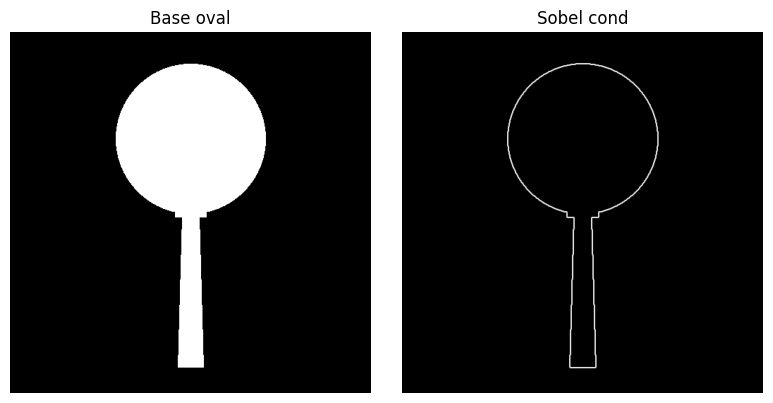

Sobel bootstrapping image ready.


In [5]:
from controlnet_aux import HEDdetector
hed = HEDdetector.from_pretrained('lllyasviel/Annotators')

base_image_pil, base_tensor = build_base_image(device)
with torch.no_grad():
    sobel_pil = T.ToPILImage()(sobel_proxy(base_tensor, device).squeeze(0).cpu())

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(base_image_pil);         axes[0].set_title('Base oval');   axes[0].axis('off')
axes[1].imshow(sobel_pil, cmap='gray'); axes[1].set_title('Sobel cond'); axes[1].axis('off')
plt.tight_layout(); display(fig); plt.close()
print('Sobel bootstrapping image ready.')

## 6. Helper functions

In [6]:
# ── Image generation ───────────────────────────────────────────────────────

def generate_images(pipe, prompt, cond_pil, n, seed=None):
    """Generate n images from a ControlNet pipe conditioned on cond_pil.
    Used for BOTH target building and condition evaluation —
    the CLIP embedding is always built directly from the returned PIL images."""
    pipe.vae.to(dtype=torch.float16)
    gen = torch.Generator(device=pipe.device).manual_seed(seed) if seed is not None else None
    images = []
    with torch.no_grad():
        for start in range(0, n, BATCH_SIZE):
            bs = min(BATCH_SIZE, n - start)
            result = pipe(
                prompt=[prompt] * bs,
                image=[cond_pil] * bs,
                num_inference_steps=N_STEPS_FAST,
                guidance_scale=0.0,
                controlnet_conditioning_scale=CONTROLNET_SCALE,
                output_type='pil',
                generator=gen,
            )
            images.extend(result.images)
            print(f'  {len(images)}/{n}', end='\r')
    pipe.vae.to(dtype=torch.float32)
    print()
    return images


# ── CLIP embeddings ────────────────────────────────────────────────────────

def clip_embed(images):
    """Encode a list of PIL images → CLIP embeddings [N, D]."""
    tensors = torch.cat([TF.to_tensor(img).unsqueeze(0) for img in images]).to(device)
    clip_model.to(device)
    with torch.no_grad():
        embs = encode_images_clip(tensors, clip_model, clip_processor)
    clip_model.to('cpu')
    return embs


def encode_text_prompts(prompts):
    """Encode text prompts → L2-normalised CLIP embeddings [N, D]."""
    clip_model.to(device)
    inputs = clip_processor(text=prompts, return_tensors='pt', padding=True).to(device)
    with torch.no_grad():
        out       = clip_model.text_model(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask']
        )
        text_embs = clip_model.text_projection(out.pooler_output)
    clip_model.to('cpu')
    return F.normalize(text_embs, dim=-1)


# ── Classification ─────────────────────────────────────────────────────────

def classify_binary_gender(images):
    """Binary man/woman CLIP-softmax. Returns n_male (int), pct_male (float 0–100)."""
    res, _ = compute_clip_softmax(images, clip_model, clip_processor,
                                   MAN_PROMPT, WOMAN_PROMPT, device)
    n_male = sum(1 for r in res if r['label'] == 'male')
    return n_male, n_male / len(res) * 100


def classify_multinomial(image_embs, text_embs):
    """k-way cosine-softmax classification.
    Returns labels [N], probs [N,C], proportions [C]."""
    img_n  = F.normalize(image_embs.float(), dim=-1)
    logits = img_n @ text_embs.T.float()
    probs  = torch.softmax(logits * 100, dim=-1).cpu().numpy()
    labels = probs.argmax(axis=1).tolist()
    props  = np.bincount(labels, minlength=text_embs.shape[0]) / len(labels)
    return labels, probs, props


# ── Confidence intervals ───────────────────────────────────────────────────

def binomial_ci(n_success, n_total, z=1.96):
    p  = n_success / n_total
    se = np.sqrt(p * (1 - p) / n_total)
    return float(p), float(p - z * se), float(p + z * se)


def multinomial_ci(counts, n_total, z=1.96):
    p  = counts / n_total
    se = np.sqrt(p * (1 - p) / n_total)
    return p, p - z * se, p + z * se


# ── HED bootstrapping ──────────────────────────────────────────────────────

def bootstrap_hed(prompt, seed):
    """Generate one portrait via Sobel-conditioned ControlNet,
    then extract its HED scribble.
    Returns (portrait_pil, hed_scribble_pil)."""
    imgs = generate_images(sprinter, prompt, sobel_pil, 1, seed=seed)
    scr  = hed(imgs[0], scribble=True)
    return imgs[0], scr


# ── SDEdit ─────────────────────────────────────────────────────────────────

def run_sdedit(scr_pil, seed, sdedit_prompt):
    """Encode scr_pil → add noise at SDEDIT_START → denoise with sdedit_prompt."""
    architect.vae.to(dtype=torch.float32)
    architect.scheduler.set_timesteps(N_STEPS_ARCH, device=device)
    timesteps = architect.scheduler.timesteps

    with torch.no_grad():
        t      = TF.to_tensor(scr_pil.convert('RGB')).unsqueeze(0).to(device).float()
        t      = (t * 2.0) - 1.0
        latent = architect.vae.encode(t).latent_dist.mean * architect.vae.config.scaling_factor

    t_start = timesteps[SDEDIT_START]
    alpha   = architect.scheduler.alphas_cumprod.to(device)[t_start.long()].float()
    gen     = torch.Generator(device=device).manual_seed(seed)
    noise   = torch.randn(latent.shape, generator=gen, device=device, dtype=torch.float32)
    latents = ((alpha ** 0.5) * latent + ((1 - alpha) ** 0.5) * noise).half()

    with torch.no_grad():
        prompt_embeds, neg_embeds, pooled, neg_pooled = architect.encode_prompt(
            prompt=sdedit_prompt, negative_prompt='', device=device,
            do_classifier_free_guidance=True, num_images_per_prompt=1,
        )
    add_ids = torch.tensor([[512, 512, 0, 0, 512, 512]], dtype=prompt_embeds.dtype, device=device)
    added   = {'text_embeds': torch.cat([neg_pooled, pooled]),
               'time_ids':    add_ids.repeat(2, 1)}
    cfg_st  = torch.cat([neg_embeds, prompt_embeds])

    sched = copy.deepcopy(architect.scheduler)
    with torch.no_grad():
        for t in timesteps[SDEDIT_START:]:
            lmi     = sched.scale_model_input(torch.cat([latents] * 2), t)
            out     = architect.unet(lmi, t, encoder_hidden_states=cfg_st,
                                     added_cond_kwargs=added, return_dict=False)[0]
            nu, nc  = out.chunk(2)
            latents = sched.step(nu + SDEDIT_CFG * (nc - nu), t, latents).prev_sample

    with torch.no_grad():
        dec = architect.vae.decode(
            (latents.float() / architect.vae.config.scaling_factor).to(architect.vae.dtype)
        ).sample
        pil = T.ToPILImage()(
            torch.clamp((dec.float() + 1.0) / 2.0, 0.0, 1.0).squeeze(0).cpu()
        )
    return pil


# ── Random scribble perturbations ──────────────────────────────────────────

def perturb_scribble(base_pil, rng_seed, noise_std=15, blur_range=(0.0, 2.0)):
    """Gaussian-noise + optional-blur perturbation of a HED scribble."""
    rng = np.random.RandomState(rng_seed)
    arr = np.array(base_pil).astype(np.float32)
    arr = (arr + rng.normal(0, noise_std, arr.shape)).clip(0, 255).astype(np.uint8)
    pil = Image.fromarray(arr)
    blur = rng.uniform(*blur_range)
    if blur > 0.3:
        pil = pil.filter(ImageFilter.GaussianBlur(radius=blur))
    return pil


def search_random_best(base_scr, proxy_target, gen_seed_base, n_proxy):
    """Try N_RANDOM random perturbations of base_scr.
    Returns (best_scr, best_mmd, all_mmds)."""
    best_scr, best_mmd, all_mmds = None, float('inf'), []
    for i in range(N_RANDOM):
        cand = perturb_scribble(base_scr, rng_seed=gen_seed_base + i)
        imgs = generate_images(sprinter, NEUTRAL_PROMPT, cand, n_proxy,
                               seed=gen_seed_base + i)
        embs = clip_embed(imgs)
        mmd  = compute_mmd(embs, proxy_target.detach()).item()
        all_mmds.append(float(mmd))
        if mmd < best_mmd:
            best_mmd = mmd
            best_scr = cand.copy()
        print(f'    rand {i+1:3d}/{N_RANDOM}  mmd={mmd:.5f}  best={best_mmd:.5f}', end='\r')
    print()
    return best_scr, float(best_mmd), all_mmds


# ── Eval shortcut ──────────────────────────────────────────────────────────

def eval_scribble(scribble_pil, target_clip, n, seed=None):
    """Generate n images from scribble → CLIP embed → MMD + SWD.
    Returns (imgs, embs, mmd, swd)."""
    imgs = generate_images(sprinter, NEUTRAL_PROMPT, scribble_pil, n, seed=seed)
    embs = clip_embed(imgs)
    mmd  = compute_mmd(embs, target_clip.detach()).item()
    swd  = compute_swd(embs, target_clip.detach()).item()
    return imgs, embs, float(mmd), float(swd)


# ── Result enrichment (classification + CI) ────────────────────────────────

def enrich_binary_gender(result, imgs, n_total):
    n_male, _ = classify_binary_gender(imgs)
    p, lo, hi = binomial_ci(n_male, n_total)
    result.update({'n_male': int(n_male), 'n_female': int(n_total - n_male),
                   'p_male': p, 'ci_lo_male': lo, 'ci_hi_male': hi})


def enrich_gender_interp(result, embs, n_total, text_embs, labels):
    lbs, _, _  = classify_multinomial(embs, text_embs)
    counts     = np.bincount(lbs, minlength=len(labels))
    p, lo, hi  = multinomial_ci(counts, n_total)
    result.update({'class_labels': labels, 'class_counts': counts.tolist(),
                   'class_proportions': p.tolist(),
                   'class_ci_lo': lo.tolist(), 'class_ci_hi': hi.tolist()})


def enrich_age(result, embs, n_total):
    lbs, _, _  = classify_multinomial(embs, age_text_embs)
    counts     = np.bincount(lbs, minlength=N_AGES)
    p, lo, hi  = multinomial_ci(counts, n_total)
    result.update({'class_labels': age_labels, 'class_counts': counts.tolist(),
                   'class_proportions': p.tolist(),
                   'class_ci_lo': lo.tolist(), 'class_ci_hi': hi.tolist()})


# ── Utilities ──────────────────────────────────────────────────────────────

def fmt(s):
    h, r = divmod(int(s), 3600)
    m, s = divmod(r, 60)
    return f'{h:02d}:{m:02d}:{s:02d}'


def to_json(obj):
    _skip = {'scribble', 'portrait', 'config', 'build_target_fn',
             'build_source_fn', 'text_embs'}
    if isinstance(obj, dict):
        return {k: to_json(v) for k, v in obj.items() if k not in _skip}
    if isinstance(obj, list):
        return [to_json(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


print('Helpers ready.')

Helpers ready.


## 7. Pre-compute text embeddings + experiment registry

In [7]:
# ── Text embeddings for classification ────────────────────────────────────
gender_interp_labels   = [l for l, _, _ in GENDER_INTERP_CLASSES]
gender_interp_prompts  = [p for _, p, _ in GENDER_INTERP_CLASSES]
gender_interp_fracs    = [f for _, _, f in GENDER_INTERP_CLASSES]
gender_interp_text_embs = encode_text_prompts(gender_interp_prompts)  # [4, D]

age_prompts   = [AGE_PROMPT_FN(a) for a in AGE_LIST]
age_labels    = [f'age_{a}' for a in AGE_LIST]
age_fracs     = [1.0 / N_AGES] * N_AGES
age_text_embs = encode_text_prompts(age_prompts)                      # [41, D]

print(f'Gender-interp text embs : {gender_interp_text_embs.shape}')
print(f'Age text embs           : {age_text_embs.shape}')

Gender-interp text embs : torch.Size([4, 768])
Age text embs           : torch.Size([40, 768])


In [8]:
# ---------------------------------------------------------------------------
#  Target builders
#  Each generates PIL images conditioned on hed_anchor, then CLIP-embeds them.
#  No latent capture needed — the CLIP vector is built from the images directly.
# ---------------------------------------------------------------------------

def build_target_gender_ratio(hed_anchor, seed_offset, n, man_frac):
    n_man   = int(n * man_frac)
    n_woman = n - n_man
    man_imgs   = generate_images(sprinter, MAN_PROMPT,   hed_anchor, n_man,   seed=seed_offset)
    woman_imgs = generate_images(sprinter, WOMAN_PROMPT, hed_anchor, n_woman, seed=seed_offset + 500)
    return clip_embed(man_imgs + woman_imgs)


def build_target_gender_interp(hed_anchor, seed_offset, n):
    all_imgs = []
    for i, (label, prompt, frac) in enumerate(GENDER_INTERP_CLASSES):
        n_i  = int(n * frac)
        imgs = generate_images(sprinter, prompt, hed_anchor, n_i,
                               seed=seed_offset + i * 300)
        all_imgs.extend(imgs)
    return clip_embed(all_imgs)


def build_target_age(hed_anchor, seed_offset):
    """3 images per age (40–80) conditioned on hed_anchor."""
    all_imgs = []
    for i, (age, prompt) in enumerate(zip(AGE_LIST, age_prompts)):
        imgs = generate_images(sprinter, prompt, hed_anchor,
                               AGE_IMAGES_PER_AGE, seed=seed_offset + i * 10)
        all_imgs.extend(imgs)
    return clip_embed(all_imgs)   # [123, D]


# ---------------------------------------------------------------------------
#  Source scribble builders  (Sobel → portrait → HED)
#  Return dict with at minimum:
#    'anchor_scr'  : PIL  (used for SDEdit + random search)
#    'avg_scribble': PIL
#    'anchor_hed_for_target': PIL  (used to condition the target distribution)
# ---------------------------------------------------------------------------

def build_source_gender_ratio(seed, man_frac):
    _, scr_man   = bootstrap_hed(MAN_PROMPT,   seed=seed)
    _, scr_woman = bootstrap_hed(WOMAN_PROMPT, seed=seed + 1)
    woman_frac = 1.0 - man_frac
    avg_np = (
        man_frac   * np.array(scr_man).astype(np.float32) +
        woman_frac * np.array(scr_woman).astype(np.float32)
    ).clip(0, 255).astype(np.uint8)
    return {
        'anchor_scr':            scr_man,
        'anchor_hed_for_target': scr_man,
        'avg_scribble':          Image.fromarray(avg_np),
        '_scr_man':              scr_man,
        '_scr_woman':            scr_woman,
    }


def build_source_gender_interp(seed):
    class_scrs = []
    for i, (label, prompt, frac) in enumerate(GENDER_INTERP_CLASSES):
        _, scr = bootstrap_hed(prompt, seed=seed + i)
        class_scrs.append((scr, frac))
    avg_np = sum(
        f * np.array(s).astype(np.float32) for s, f in class_scrs
    ).clip(0, 255).astype(np.uint8)
    anchor_scr = class_scrs[-1][0]   # 'Man' pole
    return {
        'anchor_scr':            anchor_scr,
        'anchor_hed_for_target': anchor_scr,
        'avg_scribble':          Image.fromarray(avg_np),
        '_class_scrs':           [s for s, _ in class_scrs],
    }


def build_source_age(seed):
    age_scrs = []
    for i, (age, prompt) in enumerate(zip(AGE_LIST, age_prompts)):
        _, scr = bootstrap_hed(prompt, seed=seed + i)
        age_scrs.append(scr)
    avg_np = (
        sum(np.array(s).astype(np.float32) for s in age_scrs) / N_AGES
    ).clip(0, 255).astype(np.uint8)
    anchor_scr = age_scrs[0]   # youngest age
    return {
        'anchor_scr':            anchor_scr,
        'anchor_hed_for_target': anchor_scr,
        'avg_scribble':          Image.fromarray(avg_np),
        '_age_scrs':             age_scrs,
    }


# ---------------------------------------------------------------------------
#  Experiment registry
# ---------------------------------------------------------------------------

ALL_EXPERIMENTS = [
    {
        'name':          '50_50',
        'description':   '50% man / 50% woman',
        'n_proxy':       N_PROXY_DEFAULT,
        'eval_type':     'binary_gender',
        'class_labels':  ['man', 'woman'],
        'class_fracs':   [0.5, 0.5],
        'sdedit_prompt': SDEDIT_PROMPT_BALANCED,
        'build_source_fn':  lambda seed: build_source_gender_ratio(seed, man_frac=0.5),
        'build_target_fn':  lambda anc, so, n: build_target_gender_ratio(anc, so, n, man_frac=0.5),
    },
    {
        'name':          '25_75',
        'description':   '25% man / 75% woman',
        'n_proxy':       N_PROXY_DEFAULT,
        'eval_type':     'binary_gender',
        'class_labels':  ['man', 'woman'],
        'class_fracs':   [0.25, 0.75],
        'sdedit_prompt': SDEDIT_PROMPT_SKEWED,
        'build_source_fn':  lambda seed: build_source_gender_ratio(seed, man_frac=0.25),
        'build_target_fn':  lambda anc, so, n: build_target_gender_ratio(anc, so, n, man_frac=0.25),
    },
    {
        'name':          'gender_interp',
        'description':   '4-class gender spectrum (each 25%)',
        'n_proxy':       N_PROXY_DEFAULT,
        'eval_type':     'gender_interp',
        'class_labels':  gender_interp_labels,
        'class_fracs':   gender_interp_fracs,
        'sdedit_prompt': SDEDIT_PROMPT_INTERP,
        'build_source_fn':  build_source_gender_interp,
        'build_target_fn':  lambda anc, so, n: build_target_gender_interp(anc, so, n),
    },
    {
        'name':          'age_interp',
        'description':   f'Uniform ages {AGE_MIN}–{AGE_MAX} men ({N_PROXY_AGE} proxy images)',
        'n_proxy':       N_PROXY_AGE,
        'eval_type':     'age',
        'class_labels':  age_labels,
        'class_fracs':   age_fracs,
        'sdedit_prompt': SDEDIT_PROMPT_AGE,
        'build_source_fn':  build_source_age,
        'build_target_fn':  lambda anc, so, n: build_target_age(anc, so),
    },
]

print('Experiments:', [e['name'] for e in ALL_EXPERIMENTS])
print('SDEdit prompts per experiment:')
for e in ALL_EXPERIMENTS:
    print(f'  {e["name"]:<15} → {e["sdedit_prompt"]}')

Experiments: ['50_50', '25_75', 'gender_interp', 'age_interp']
SDEdit prompts per experiment:
  50_50           → a face scribble sketch of man or woman
  25_75           → a face scribble sketch, mostly feminine features sometimes with masculine features
  gender_interp   → a face scribble sketch, with a range of feminine to masculine features
  age_interp      → a face scribble sketch of a person at various ages between 40 to 79


## 8. Main experiment loop

In [ ]:
all_experiment_results = {}

for exp in ALL_EXPERIMENTS:
    exp_name = exp['name']
    n_proxy  = exp['n_proxy']
    exp_dir  = os.path.join(CHECKPOINT_DIR, exp_name)
    os.makedirs(exp_dir, exist_ok=True)

    print(f"\n{'#'*68}")
    print(f'  EXPERIMENT : {exp_name}  —  {exp["description"]}')
    print(f'  proxy N    : {n_proxy}   SDEdit: {exp["sdedit_prompt"]}')
    print(f"{'#'*68}")

    all_records     = []
    seed_times      = {}
    best_per_method = {c: {'seed': None, 'mmd': float('inf'), 'scribble': None}
                       for c in CONDITION_NAMES}

    for seed in range(1, N_RUNS + 1):
        t_seed_start = time.time()
        print(f"\n{'='*55}")
        print(f'  {exp_name}  |  SEED {seed}/{N_RUNS}')
        print(f"{'='*55}")

        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        np.random.seed(seed)

        seed_dir = os.path.join(exp_dir, f'seed_{seed:02d}')
        os.makedirs(seed_dir, exist_ok=True)

        # ── (A) Build source scribbles via Sobel → HED bootstrapping ────────
        t_a = time.time()
        print('  [A] Source scribbles (Sobel→portrait→HED)...')
        src        = exp['build_source_fn'](seed)
        anchor_scr = src['anchor_scr']            # anchor for SDEdit + random
        hed_anchor = src['anchor_hed_for_target']  # anchor for target generation
        print(f'      done in {fmt(time.time() - t_a)}')

        # Save scribbles
        anchor_scr.save(os.path.join(seed_dir, 'scribble_anchor.png'))
        src['avg_scribble'].save(os.path.join(seed_dir, 'scribble_avg.png'))
        if '_scr_man' in src:
            src['_scr_man'].save(os.path.join(seed_dir, 'scribble_man.png'))
            src['_scr_woman'].save(os.path.join(seed_dir, 'scribble_woman.png'))
        if '_class_scrs' in src:
            for i, (lbl, _, _) in enumerate(GENDER_INTERP_CLASSES):
                safe = lbl.lower().replace(' ', '_').replace('+', '_')
                src['_class_scrs'][i].save(os.path.join(seed_dir, f'scribble_{safe}.png'))
        if '_age_scrs' in src:
            for idx in [0, N_AGES // 2, -1]:
                src['_age_scrs'][idx].save(
                    os.path.join(seed_dir, f'scribble_age_{AGE_LIST[idx]}.png'))

        # ── (B) Build proxy target (HED-conditioned, CLIP from images) ───────
        t_b = time.time()
        print('  [B] Proxy target (HED-conditioned images → CLIP embed)...')
        proxy_target = exp['build_target_fn'](hed_anchor, seed * 1000, n_proxy)
        print(f'      shape={proxy_target.shape}  done in {fmt(time.time() - t_b)}')

        # ── (C) SDEdit scribble ──────────────────────────────────────────────
        t_c = time.time()
        print(f'  [C] SDEdit  prompt="{exp["sdedit_prompt"][:50]}..."')
        scr_sdedit = run_sdedit(anchor_scr, seed, exp['sdedit_prompt'])
        scr_sdedit.save(os.path.join(seed_dir, 'scribble_sdedit.png'))
        print(f'      done in {fmt(time.time() - t_c)}')

        # ── (D) Random best search ───────────────────────────────────────────
        t_d = time.time()
        print(f'  [D] Random best ({N_RANDOM} candidates, {n_proxy} eval images each)...')
        scr_rand, rand_best_mmd, rand_all_mmds = search_random_best(
            anchor_scr, proxy_target,
            gen_seed_base=seed * 100000,
            n_proxy=n_proxy,
        )
        scr_rand.save(os.path.join(seed_dir, 'scribble_random_best.png'))
        print(f'      best_mmd={rand_best_mmd:.5f}  done in {fmt(time.time() - t_d)}')

        # ── (E) Evaluate all conditions + anchor baseline ────────────────────
        run_conditions = {
            'avg_scribble':          src['avg_scribble'],
            'sdedit_scribble':       scr_sdedit,
            'random_best_scribble':  scr_rand,
            'anchor_scribble':       anchor_scr,   # baseline reference only
        }

        seed_results = {'rand_all_mmds': rand_all_mmds}

        for cond_name, scribble in run_conditions.items():
            t_e = time.time()
            print(f'  [E] [{cond_name}]...')
            imgs, embs, mmd, _ = eval_scribble(scribble, proxy_target, n_proxy, seed=seed)
            seed_results[cond_name] = {'mmd': mmd, 'time_s': round(time.time() - t_e, 1)}

            record = {'seed': seed, 'condition': cond_name, 'mmd': mmd}
            if exp['eval_type'] == 'binary_gender':
                n_male, pct = classify_binary_gender(imgs)
                record['pct_male'] = pct
                print(f'      MMD={mmd:.5f}  male={pct:.1f}%')
            else:
                print(f'      MMD={mmd:.5f}')

            all_records.append(record)

            # Track best (optimised conditions only)
            if cond_name in CONDITION_NAMES and mmd < best_per_method[cond_name]['mmd']:
                best_per_method[cond_name].update(
                    {'mmd': mmd, 'seed': seed, 'scribble': scribble.copy()}
                )

        # ── Timing ──────────────────────────────────────────────────────────
        t_total = time.time() - t_seed_start
        seed_results['total_time_s'] = round(t_total, 1)
        seed_times[seed]             = t_total
        print(f'  SEED {seed} total: {fmt(t_total)}')

        with open(os.path.join(seed_dir, 'results.json'), 'w') as f:
            json.dump(to_json(seed_results), f, indent=2)

    all_experiment_results[exp_name] = {
        'all_records':     all_records,
        'best_per_method': best_per_method,
        'seed_times':      seed_times,
    }
    print(f'\nExperiment {exp_name} done.  '
          f'Mean seed time: {fmt(np.mean(list(seed_times.values())))}')

print('\n=== All experiment loops complete. ===')


####################################################################
  EXPERIMENT : 50_50  —  50% man / 50% woman
  proxy N    : 100   SDEdit: a face scribble sketch of man or woman
####################################################################

  50_50  |  SEED 1/10
  [A] Source scribbles (Sobel→portrait→HED)...


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/controlnet/pipeline_controlnet_sd_xl.py:928: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


  1/1
  1/1
      done in 00:00:02
  [B] Proxy target (HED-conditioned images → CLIP embed)...
  50/50
  50/50
      shape=torch.Size([100, 768])  done in 00:00:26
  [C] SDEdit  prompt="a face scribble sketch of man or woman..."
      done in 00:00:13
  [D] Random best (50 candidates, 100 eval images each)...
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
  100/100
    rand  50/50  mmd=0.50363  best=0.47814
      best_mmd=0.47814  done in 00:22:13
  [E] [avg_scribble]...
  100/100
      [SWD] n_proj=20  swd=0.014918  delta=0.006726
      [SWD] n_proj=

## 9. Save best scribbles

In [ ]:
for exp in ALL_EXPERIMENTS:
    exp_name        = exp['name']
    best_per_method = all_experiment_results[exp_name]['best_per_method']
    best_dir_exp    = os.path.join(BEST_DIR, exp_name)
    os.makedirs(best_dir_exp, exist_ok=True)

    print(f'\n[{exp_name}] Best scribbles:')
    for cond, info in best_per_method.items():
        if info['scribble'] is not None:
            path = os.path.join(best_dir_exp, f'best_{cond}.png')
            info['scribble'].save(path)
            print(f'  {cond:<28}  seed={info["seed"]}  proxy_mmd={info["mmd"]:.5f}')

    fig, axes = plt.subplots(1, len(CONDITION_NAMES), figsize=(7 * len(CONDITION_NAMES), 4))
    for ax, cond in zip(axes, CONDITION_NAMES):
        info = best_per_method[cond]
        if info['scribble'] is not None:
            ax.imshow(info['scribble'], cmap='gray')
        ax.set_title(f'{cond}\nseed={info["seed"]}  MMD={info["mmd"]:.4f}', fontsize=9)
        ax.axis('off')
    plt.suptitle(f'Best scribble per method — {exp_name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(best_dir_exp, 'best_grid.png'), dpi=120)
    display(fig); plt.close()

## 10. Final evaluation (N=2000)

In [ ]:
FINAL_SEED        = 9999
all_final_results = {}

for exp in ALL_EXPERIMENTS:
    exp_name        = exp['name']
    best_per_method = all_experiment_results[exp_name]['best_per_method']
    best_dir_exp    = os.path.join(BEST_DIR, exp_name)

    print(f"\n{'='*60}")
    print(f'  FINAL EVAL : {exp_name}')
    print(f"{'='*60}")

    # ── Build final HED anchor + target (same bootstrapping protocol) ────────
    print('  Bootstrapping final HED anchor (FINAL_SEED)...')
    src_final    = exp['build_source_fn'](FINAL_SEED)
    final_anchor = src_final['anchor_hed_for_target']
    final_anchor.save(os.path.join(best_dir_exp, 'final_anchor_scribble.png'))

    print(f'  Building final target ({N_FINAL} images → CLIP embed)...')
    final_target = exp['build_target_fn'](final_anchor, FINAL_SEED, N_FINAL)
    print(f'  Target shape: {final_target.shape}')

    final_results_exp = {}

    for cond in CONDITION_NAMES:
        info = best_per_method[cond]
        if info['scribble'] is None:
            print(f'  [{cond}] skipped — no scribble found')
            continue

        t0 = time.time()
        print(f'\n  [{cond}]  generating {N_FINAL} images...')
        imgs, embs, mmd, swd = eval_scribble(info['scribble'], final_target, N_FINAL,
                                              seed=FINAL_SEED)
        result = {
            'mmd':       mmd,
            'swd':       swd,
            'best_seed': info['seed'],
            'time_s':    round(time.time() - t0, 1),
        }

        # Classification + CI
        if exp['eval_type'] == 'binary_gender':
            enrich_binary_gender(result, imgs, N_FINAL)
            print(f'  MMD={mmd:.5f}  SWD={swd:.5f}  '
                  f'p(male)={result["p_male"]:.3f}  '
                  f'95%CI=[{result["ci_lo_male"]:.3f},{result["ci_hi_male"]:.3f}]')
        elif exp['eval_type'] == 'gender_interp':
            enrich_gender_interp(result, embs, N_FINAL,
                                  gender_interp_text_embs, gender_interp_labels)
            print(f'  MMD={mmd:.5f}  SWD={swd:.5f}')
            for lbl, p, lo, hi in zip(result['class_labels'],
                                       result['class_proportions'],
                                       result['class_ci_lo'],
                                       result['class_ci_hi']):
                print(f'    {lbl:<20} p={p:.3f}  95%CI=[{lo:.3f},{hi:.3f}]')
        elif exp['eval_type'] == 'age':
            enrich_age(result, embs, N_FINAL)
            print(f'  MMD={mmd:.5f}  SWD={swd:.5f}')
            for idx in [0, N_AGES // 2, -1]:
                lbl = result['class_labels'][idx]
                p   = result['class_proportions'][idx]
                lo  = result['class_ci_lo'][idx]
                hi  = result['class_ci_hi'][idx]
                print(f'    {lbl:<12} p={p:.3f}  95%CI=[{lo:.3f},{hi:.3f}]')

        # ── Base (anchor) scribble evaluation ────────────────────────────────
        print(f'  Evaluating base anchor scribble (from seed {info["seed"]})...')
        src_base = exp['build_source_fn'](info['seed'])
        base_scr = src_base['anchor_scr']
        base_scr.save(os.path.join(best_dir_exp, f'base_anchor_for_{cond}.png'))

        base_imgs, base_embs, base_mmd, base_swd = eval_scribble(
            base_scr, final_target, N_FINAL, seed=FINAL_SEED
        )
        result['base_mmd']            = base_mmd
        result['base_swd']            = base_swd
        result['mmd_improvement']     = float(base_mmd - mmd)
        result['mmd_improvement_pct'] = float((base_mmd - mmd) / max(base_mmd, 1e-9) * 100)

        if exp['eval_type'] == 'binary_gender':
            base_res = {}
            enrich_binary_gender(base_res, base_imgs, N_FINAL)
            result['base_p_male']     = base_res['p_male']
            result['base_ci_lo_male'] = base_res['ci_lo_male']
            result['base_ci_hi_male'] = base_res['ci_hi_male']

        print(f'  base_mmd={base_mmd:.5f}  '
              f'improvement={result["mmd_improvement"]:.5f} '
              f'({result["mmd_improvement_pct"]:.1f}%)')

        final_results_exp[cond] = result

    all_final_results[exp_name] = final_results_exp

print('\n=== Final evaluations complete. ===')

## 11. Results summary tables

In [ ]:
import pandas as pd

for exp in ALL_EXPERIMENTS:
    exp_name          = exp['name']
    all_records       = all_experiment_results[exp_name]['all_records']
    final_results_exp = all_final_results[exp_name]
    seed_times        = all_experiment_results[exp_name]['seed_times']

    print(f"\n{'='*72}")
    print(f'  {exp_name}  —  {exp["description"]}')
    print(f"  SDEdit prompt: {exp['sdedit_prompt']}")
    print(f"{'='*72}")

    # Per-run proxy summary
    run_rows = {}
    for cond in CONDITION_NAMES:
        recs = [r for r in all_records if r['condition'] == cond]
        row  = {
            'MMD mean': round(np.mean([r['mmd'] for r in recs]), 5),
            'MMD std':  round(np.std( [r['mmd'] for r in recs]), 5),
        }
        if exp['eval_type'] == 'binary_gender':
            pcts = [r['pct_male'] for r in recs if 'pct_male' in r]
            row['%male mean'] = round(np.mean(pcts), 1) if pcts else None
        run_rows[cond] = row
    print(f'Per-run proxy (N={exp["n_proxy"]} per seed):')
    display(pd.DataFrame(run_rows).T)

    # Timing
    times = list(seed_times.values())
    print(f'Seed timing — mean: {fmt(np.mean(times))}  '
          f'std: {fmt(np.std(times))}  '
          f'total: {fmt(np.sum(times))}')

    # Final evaluation
    final_rows = {}
    for cond, r in final_results_exp.items():
        row = {
            'best_seed':   r['best_seed'],
            'MMD (opt)':   f"{r['mmd']:.5f}",
            'MMD (base)':  f"{r['base_mmd']:.5f}",
            'improvement': f"{r['mmd_improvement']:.5f} ({r['mmd_improvement_pct']:.1f}%)",
            'SWD (opt)':   f"{r['swd']:.5f}",
        }
        if exp['eval_type'] == 'binary_gender':
            row['p(male) opt']  = f"{r['p_male']:.3f} [{r['ci_lo_male']:.3f},{r['ci_hi_male']:.3f}]"
            row['p(male) base'] = f"{r['base_p_male']:.3f} [{r['base_ci_lo_male']:.3f},{r['base_ci_hi_male']:.3f}]"
        final_rows[cond] = row
    print(f'Final evaluation (N={N_FINAL}):')
    display(pd.DataFrame(final_rows).T)

## 12. Visualisations

In [ ]:
for exp in ALL_EXPERIMENTS:
    exp_name          = exp['name']
    all_records       = all_experiment_results[exp_name]['all_records']
    final_results_exp = all_final_results[exp_name]
    seed_times        = all_experiment_results[exp_name]['seed_times']
    best_dir_exp      = os.path.join(BEST_DIR, exp_name)
    conds_ok          = [c for c in CONDITION_NAMES if c in final_results_exp]

    # ── MMD bar chart ────────────────────────────────────────────────────────
    means      = [np.mean([r['mmd'] for r in all_records if r['condition'] == c]) for c in conds_ok]
    stds       = [np.std( [r['mmd'] for r in all_records if r['condition'] == c]) for c in conds_ok]
    final_mmds = [final_results_exp[c]['mmd']      for c in conds_ok]
    base_mmds  = [final_results_exp[c]['base_mmd'] for c in conds_ok]

    x = np.arange(len(conds_ok))
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(x - 0.28, means,      0.25, yerr=stds, capsize=4, alpha=0.8,
           label=f'Proxy mean±std (N={exp["n_proxy"]})')
    ax.bar(x,        final_mmds, 0.25, alpha=0.8, label=f'Final optimised (N={N_FINAL})')
    ax.bar(x + 0.28, base_mmds,  0.25, alpha=0.6, color='gray', label='Base anchor')
    ax.set_xticks(x); ax.set_xticklabels(conds_ok, rotation=15, ha='right')
    ax.set_ylabel('MMD'); ax.set_title(f'MMD vs target — {exp_name}')
    ax.legend(); ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(best_dir_exp, 'mmd_comparison.png'), dpi=120)
    display(fig); plt.close()

    # ── Timing ──────────────────────────────────────────────────────────────
    seeds_s = sorted(seed_times.keys())
    times_m = [seed_times[s] / 60 for s in seeds_s]
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.bar(seeds_s, times_m, color='steelblue', alpha=0.8)
    ax.axhline(np.mean(times_m), color='red', linestyle='--', linewidth=1,
               label=f'Mean {np.mean(times_m):.1f} min')
    ax.set_xlabel('Seed'); ax.set_ylabel('Time (min)')
    ax.set_title(f'Per-seed wall-clock time — {exp_name}')
    ax.legend(); ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(best_dir_exp, 'seed_timing.png'), dpi=120)
    display(fig); plt.close()

    # ── Binary gender CI ─────────────────────────────────────────────────────
    if exp['eval_type'] == 'binary_gender':
        target_p = exp['class_fracs'][0]
        p_opt  = [final_results_exp[c]['p_male']      for c in conds_ok]
        ci_lo  = [final_results_exp[c]['ci_lo_male']  for c in conds_ok]
        ci_hi  = [final_results_exp[c]['ci_hi_male']  for c in conds_ok]
        p_base = [final_results_exp[c].get('base_p_male', np.nan) for c in conds_ok]
        errs   = [[p - lo for p, lo in zip(p_opt, ci_lo)],
                  [hi - p for p, hi in zip(p_opt, ci_hi)]]

        fig, ax = plt.subplots(figsize=(9, 4))
        ax.errorbar(conds_ok, p_opt, yerr=errs, fmt='o', capsize=6,
                    linewidth=1.5, label='Optimised')
        ax.scatter(conds_ok, p_base, marker='x', s=80, color='gray',
                   zorder=5, label='Base anchor')
        ax.axhline(target_p, color='green', linestyle='--', linewidth=1,
                   label=f'Target p(male)={target_p}')
        ax.set_ylabel('p(male)'); ax.set_ylim(0, 1)
        ax.set_title(f'Proportion male — 95% CI — {exp_name} (N={N_FINAL})')
        ax.legend(); ax.grid(True, axis='y', alpha=0.3)
        plt.xticks(rotation=15, ha='right')
        plt.tight_layout()
        plt.savefig(os.path.join(best_dir_exp, 'gender_ci.png'), dpi=120)
        display(fig); plt.close()

    # ── Multi-class proportion plot ──────────────────────────────────────────
    elif exp['eval_type'] in ('gender_interp', 'age'):
        n_cls   = len(exp['class_labels'])
        n_conds = len(conds_ok)
        x_cls   = np.arange(n_cls)
        width   = 0.8 / n_conds
        colors  = plt.cm.tab10(np.linspace(0, 0.9, n_conds))

        fig, ax = plt.subplots(figsize=(max(12, n_cls // 2), 5))
        for i, (cond, color) in enumerate(zip(conds_ok, colors)):
            r     = final_results_exp[cond]
            props = np.array(r['class_proportions'])
            lo    = np.array(r['class_ci_lo'])
            hi    = np.array(r['class_ci_hi'])
            off   = (i - n_conds / 2 + 0.5) * width
            ax.bar(x_cls + off, props, width, color=color, alpha=0.75, label=cond)
            ax.errorbar(x_cls + off, props,
                        yerr=[props - lo, hi - props],
                        fmt='none', color='black', capsize=3, linewidth=1)
        for j, frac in enumerate(exp['class_fracs']):
            ax.hlines(frac, j - 0.4, j + 0.4,
                      colors='gray', linestyles='--', linewidth=1.2)

        tick_labels = exp['class_labels']
        if exp['eval_type'] == 'age' and n_cls > 15:
            tick_labels = [lbl if i % 5 == 0 else ''
                           for i, lbl in enumerate(exp['class_labels'])]
        ax.set_xticks(x_cls)
        ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Proportion')
        ax.set_title(f'Per-class proportions 95% CI (dashed=target) — {exp_name}')
        ax.set_ylim(0, 1); ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(best_dir_exp, 'class_proportions.png'), dpi=120)
        display(fig); plt.close()

## 13. Save all results to JSON

In [ ]:
per_seed_path     = os.path.join(SAVE_DIR, 'all_run_records.json')
final_path        = os.path.join(SAVE_DIR, 'final_results.json')
best_summary_path = os.path.join(SAVE_DIR, 'best_seeds_summary.json')
timing_path       = os.path.join(SAVE_DIR, 'timing.json')

with open(per_seed_path, 'w') as f:
    json.dump(
        {exp['name']: to_json(all_experiment_results[exp['name']]['all_records'])
         for exp in ALL_EXPERIMENTS}, f, indent=2)

with open(final_path, 'w') as f:
    json.dump(
        {exp['name']: to_json(all_final_results[exp['name']])
         for exp in ALL_EXPERIMENTS}, f, indent=2)

with open(best_summary_path, 'w') as f:
    json.dump(
        {exp['name']: {cond: {'seed': info['seed'], 'proxy_mmd': info['mmd']}
                       for cond, info in
                       all_experiment_results[exp['name']]['best_per_method'].items()}
         for exp in ALL_EXPERIMENTS}, f, indent=2)

with open(timing_path, 'w') as f:
    json.dump(
        {exp['name']: {
            'seed_times_s': all_experiment_results[exp['name']]['seed_times'],
            'mean_s':  float(np.mean(list(all_experiment_results[exp['name']]['seed_times'].values()))),
            'total_s': float(np.sum( list(all_experiment_results[exp['name']]['seed_times'].values()))),
         } for exp in ALL_EXPERIMENTS}, f, indent=2)

for p in [per_seed_path, final_path, best_summary_path, timing_path]:
    print(f'Saved → {p}')

## 14. Auto-download all files

In [ ]:
import zipfile
from google.colab import files

# 1. JSON files
for p in [per_seed_path, final_path, best_summary_path, timing_path]:
    print(f'Downloading {os.path.basename(p)} ...')
    files.download(p)

# 2. Best scribbles zip
best_zip = f'/content/{EXPERIMENT_NAME}_best_scribbles.zip'
print(f'\nZipping best scribbles → {best_zip}')
with zipfile.ZipFile(best_zip, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, fs in os.walk(BEST_DIR):
        for fname in fs:
            fpath = os.path.join(root, fname)
            zf.write(fpath, os.path.relpath(fpath, BEST_DIR))
files.download(best_zip)

# 3. Full checkpoints zip
ckpt_zip = f'/content/{EXPERIMENT_NAME}_checkpoints.zip'
print(f'Zipping checkpoints → {ckpt_zip}')
with zipfile.ZipFile(ckpt_zip, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, fs in os.walk(CHECKPOINT_DIR):
        for fname in fs:
            fpath = os.path.join(root, fname)
            zf.write(fpath, os.path.relpath(fpath, CHECKPOINT_DIR))
files.download(ckpt_zip)

print('\nAll downloads initiated.')